# Q9 — Modelo preditivo de risco de piora da adequação de nível

**Datathon Passos Mágicos · POSTECH Data Analytics · Fase 5**

**Pergunta do enunciado:** *quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem? Construa um modelo preditivo que mostre uma probabilidade do aluno entrar em risco de defasagem.*

## Evento previsto

**Redução de D no ano seguinte**, com D = fase efetiva − fase ideal: `D[t+1] < D[t]`. Em linguagem gerencial, é a **piora da adequação de nível**, ou o aumento da defasagem na definição da PEDE.

O evento **não** equivale à retenção de fase nem à entrada em defasagem. Ele reúne três situações, separadas na seção 2:
- **entrada em defasagem** (D ≥ 0 → D < 0);
- **agravamento** de quem já estava defasado;
- **perda de vantagem** de quem continua em fase.

**População.** Alunos das fases 0 a 7 presentes na base em dois anos consecutivos. A probabilidade é **condicional a o aluno aparecer no ano seguinte**; o modelo não estima risco de saída da base.

**Horizonte de uso.** Com os indicadores do **fechamento do ano t**, prever o ano t+1.

## Nota sobre a formulação (transparência)

A versão anterior usava um alvo composto (queda de IDA ≥ 0,5 **ou** piora da defasagem). Durante a revisão, **alvos alternativos foram explorados observando o desempenho em 2023→2024**, o mesmo período usado aqui como teste. Por isso, o teste é independente para a **escolha do modelo, dos hiperparâmetros, da calibração e dos limiares**, que usam só o treino, mas **não é totalmente independente da formulação do problema**. Para mitigar isso, a seção 8 reporta a validação na direção inversa (treinar em 2023→24 e testar em 2022→23) e o desempenho do alvo anterior sob o mesmo protocolo.

**Estrutura:** 1. Dados · 2. Alvo · 3. Atributos · 4. Separação temporal · 5. Seleção (só treino) · 6. Avaliação no teste · 7. Interpretação · 8. Robustez e sensibilidades · 9. Modelo final · 10. Conclusões e limitações

In [1]:
import json
import sys
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import sklearn
from IPython.display import Image

RAIZ = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(RAIZ / "src"))

from config import BASE_LONGITUDINAL, MODELO_RISCO, RESULTADOS_MODELO, PASTA_PROCESSADOS, PASTA_FIGURAS
from features import (ALVO, ALVO_SENSIBILIDADE, ATRIBUTOS, DESCRICAO_ATRIBUTOS, construir_pares,
                      decompor_evento, faixa_de_risco, preparar_atributos)
from graficos import SERIES, NEUTRO, fmt_br, nova_figura, salvar

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, brier_score_loss, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import GroupKFold, StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
SEMENTE = 42
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
print("scikit-learn", sklearn.__version__, "| pandas", pd.__version__)

scikit-learn 1.9.1 | pandas 2.3.3


## 1. Dados

A base longitudinal é gerada por `src/preparacao.py`. Os indicadores da fonte são preservados; os tratamentos analíticos ficam em colunas separadas (`IAA_analise`, `IEG_analise`, `defasagem_regra`).

In [2]:
base = pd.read_csv(BASE_LONGITUDINAL)
print(base.shape)
base.groupby("ano")[["ra", "inde", "IDA", "IEG", "IPV", "IPP"]].count()

(3030, 34)


,ra,inde,IDA,IEG,IPV,IPP
ano,,,,,,
2022,860,860,860,860,860,0
2023,1014,931,937,938,938,938
2024,1156,1054,1055,1156,1054,1054


## 2. Construção do alvo

Cada aluno presente em dois anos consecutivos gera um par *(t → t+1)*. Escopo: **fases 0 a 7**, porque a Fase 8 (universitários) não tem fase seguinte comparável. Pares sem defasagem em algum dos anos seriam descartados, nunca tratados como "sem evento" (não há nenhum nesta base).

In [3]:
pares = construir_pares(base)
resumo_alvo = pares.groupby("ano")[ALVO].agg(pares="size", eventos="sum", prevalencia="mean")
resumo_alvo.index = [f"{a}→{a + 1}" for a in resumo_alvo.index]
resumo_alvo

,pares,eventos,prevalencia
2022→2023,600,104,0.173
2023→2024,706,130,0.184


**Composição do evento.** O evento mistura situações diferentes, e isso deve orientar a leitura do risco:

In [4]:
decomposicao = pd.crosstab(pares["ano"].map(lambda a: f"{a}→{a + 1}"), decompor_evento(pares))
decomposicao

col_0,Agravamento (já defasado),Entrada em defasagem,Perda de vantagem (continua em fase),Sem evento
ano,,,,
2022→2023,38,60,6,496
2023→2024,30,84,16,576


**Relação com a promoção de fase, nos dois sentidos.** Quase todo evento ocorre entre não promovidos, mas **não ser promovido não implica o evento**: a fase ideal abrange mais de uma idade, então quem fica na fase pode continuar adequado.

In [5]:
promocao = pd.crosstab(pares["promovido"].map({True: "Promovido", False: "Não promovido"}),
                       pares[ALVO].map({0: "Sem evento", 1: "Com evento"}), margins=True, margins_name="Total")
promocao["% com evento"] = promocao["Com evento"] / promocao["Total"] * 100
promocao

risco_reducao_D,Com evento,Sem evento,Total,% com evento
promovido,,,,
Não promovido,232,157,389,59.640
Promovido,2,915,917,0.218
Total,234,1072,1306,17.917


## 3. Engenharia de atributos

Todos os atributos são conhecidos **no fechamento do ano t**.

In [6]:
pd.DataFrame({"atributo": ATRIBUTOS, "descrição": [DESCRICAO_ATRIBUTOS[a] for a in ATRIBUTOS],
              "cobertura_%": [pares[a].notna().mean() * 100 for a in ATRIBUTOS]}).round(1)

,atributo,descrição,cobertura_%
0,fase,Fase atual na Passos Mágicos (ALFA = 0),100.000
1,idade,Idade registrada no ano de referência,100.000
2,idade_relativa_fase,Idade menos a idade de entrada da fase (tabela...,100.000
3,defasagem,D = fase efetiva − fase ideal (negativo = atra...,100.000
4,anos_no_programa,Anos desde o ingresso,100.000
5,genero_feminino,1 = feminino,100.000
6,escola_publica,1 = escola pública,100.000
7,IDA,Desempenho acadêmico,99.000
8,IEG,Engajamento (0 sem outras avaliações tratado c...,99.000
9,IAA,Autoavaliação (0 tratado como ausente; hipótes...,88.100


| Decisão | Motivo | Status |
|---|---|---|
| Fase, gênero e escola **harmonizados** entre anos | Os rótulos mudavam de ano para ano; na versão anterior o teste não reconhecia nenhuma categoria do treino. | Verificado |
| `idade_relativa_fase` = idade − idade de entrada da fase | Tabela oficial PEDE: ALFA 7, F1 8, F2 10, F3 12, F4 14, F5 15, F6 16, F7 17. | Verificado |
| `IAA = 0` → ausente | Zeros ocorrem com as demais avaliações presentes; **hipótese de não resposta, a confirmar**. Sensibilidade na seção 8. | Hipótese |
| `IEG = 0` sem IDA → ausente | Registros sem nenhuma outra avaliação (em 2024, Fases 8 e 9, fora do escopo do modelo). | Verificado |
| **IPS fora** | Distribuição de 2023 muito diferente dos outros anos (concentração em 2,52 e 7,52); causa **não confirmada**. Sensibilidade na seção 8. | Hipótese |
| **IPP fora** | Não existe em 2022, o ano de treino. | Verificado |
| **INDE mantido como na fonte** | É o índice oficial e inclui IAA (com zeros) e IPS. Sensibilidade sem INDE na seção 8. | Decisão |
| **IAN e Pedra fora** | Funções de defasagem e INDE (redundantes). | Verificado |
| Ausentes | Imputação pela mediana dentro do pipeline, ajustada só no treino. | — |

In [7]:
proibidas = {"defasagem_seguinte", "defasagem_regra_seguinte", "fase_seguinte", "promovido", ALVO, ALVO_SENSIBILIDADE}
assert not proibidas & set(ATRIBUTOS), "vazamento: atributo do futuro"
print("OK — nenhum atributo do ano t+1 entre os preditores.")

OK — nenhum atributo do ano t+1 entre os preditores.


## 4. Separação treino/teste temporal

- **Treino:** atributos de 2022 → alvo em 2023
- **Teste:** atributos de 2023 → alvo em 2024

No treino há uma linha por aluno. Um mesmo aluno pode aparecer no treino e no teste, em anos diferentes; a seção 8 avalia separadamente os alunos novos.

In [8]:
treino = pares[pares["ano"] == 2022].reset_index(drop=True)
teste = pares[pares["ano"] == 2023].reset_index(drop=True)
assert treino["ra"].is_unique and teste["ra"].is_unique
X_treino, y_treino = treino[ATRIBUTOS], treino[ALVO]
X_teste, y_teste = teste[ATRIBUTOS], teste[ALVO]
print(f"Treino: {len(treino)} pares | prevalência {y_treino.mean():.1%}")
print(f"Teste:  {len(teste)} pares | prevalência {y_teste.mean():.1%}")

Treino: 600 pares | prevalência 17.3%
Teste:  706 pares | prevalência 18.4%


## 5. Modelagem e seleção (somente treino)

Três famílias de modelo mais um baseline de regra simples. A seleção usa validação cruzada estratificada de 5 dobras **no treino**.

**Calibração decidida a priori.** O enunciado pede uma *probabilidade*. Por isso, antes de olhar o teste, fixou-se que o modelo escolhido seria calibrado pelo método sigmoide (Platt), com validação cruzada interna ao treino. O teste apenas mede o resultado dessa decisão.

**Métricas.** ROC-AUC mede a ordenação. **AP (average precision)** resume a curva precisão × recall; a referência de um modelo sem informação é a prevalência. Brier mede o erro das probabilidades.

In [9]:
def imputar(modelo, escalar=False):
    passos = [SimpleImputer(strategy="median")] + ([StandardScaler()] if escalar else []) + [modelo]
    return make_pipeline(*passos)

candidatos = {
    "Regressão Logística": imputar(LogisticRegression(max_iter=5000, C=1.0), escalar=True),
    "Random Forest (folha ≥ 5)": imputar(RandomForestClassifier(n_estimators=500, min_samples_leaf=5, random_state=SEMENTE, n_jobs=-1)),
    "Random Forest (folha ≥ 10)": imputar(RandomForestClassifier(n_estimators=500, min_samples_leaf=10, random_state=SEMENTE, n_jobs=-1)),
    "Random Forest (folha ≥ 20)": imputar(RandomForestClassifier(n_estimators=500, min_samples_leaf=20, random_state=SEMENTE, n_jobs=-1)),
    "Gradient Boosting": HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=200, random_state=SEMENTE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMENTE)
linhas = []
for nome, modelo in candidatos.items():
    prob = cross_val_predict(modelo, X_treino, y_treino, cv=cv, method="predict_proba")[:, 1]
    linhas.append({"modelo": nome, "ROC-AUC (CV)": roc_auc_score(y_treino, prob),
                   "AP (CV)": average_precision_score(y_treino, prob), "Brier (CV)": brier_score_loss(y_treino, prob)})
linhas.append({"modelo": "Baseline: só defasagem atual", "ROC-AUC (CV)": roc_auc_score(y_treino, X_treino["defasagem"]),
               "AP (CV)": average_precision_score(y_treino, X_treino["defasagem"]), "Brier (CV)": np.nan})
selecao = pd.DataFrame(linhas).set_index("modelo").sort_values("ROC-AUC (CV)", ascending=False)
selecao

,ROC-AUC (CV),AP (CV),Brier (CV)
modelo,,,
Random Forest (folha ≥ 20),0.832,0.486,0.114
Random Forest (folha ≥ 5),0.831,0.544,0.110
Random Forest (folha ≥ 10),0.829,0.511,0.112
Gradient Boosting,0.826,0.528,0.113
Regressão Logística,0.821,0.469,0.115
Baseline: só defasagem atual,0.735,0.324,NaN


In [10]:
nome_escolhido = selecao.drop(index="Baseline: só defasagem atual")["ROC-AUC (CV)"].idxmax()
base_escolhida = candidatos[nome_escolhido]

def calibrado(estimador, cv_calibracao):
    return CalibratedClassifierCV(clone(estimador), method="sigmoid", cv=cv_calibracao, ensemble=False)

cv_interno = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMENTE + 1)
modelo_escolhido = calibrado(base_escolhida, cv_interno)
print("Modelo escolhido pela validação cruzada no treino:", nome_escolhido, "+ calibração sigmoide")

Modelo escolhido pela validação cruzada no treino: Random Forest (folha ≥ 20) + calibração sigmoide


**Limiares operacionais**, definidos com previsões calibradas fora da dobra (*out-of-fold*) do treino, sem usar o teste:
- **Alto:** limiar que maximiza o F1.
- **Médio:** limiar que captura 85% dos eventos (recall = 0,85).

In [11]:
def limiares(y, prob):
    precisao, recall, cortes = precision_recall_curve(y, prob)
    f1 = 2 * precisao[:-1] * recall[:-1] / (precisao[:-1] + recall[:-1] + 1e-12)
    return float(cortes[np.where(recall[:-1] >= 0.85)[0].max()]), float(cortes[np.argmax(f1)])

prob_oof_treino = cross_val_predict(modelo_escolhido, X_treino, y_treino, cv=cv, method="predict_proba")[:, 1]
limiar_medio, limiar_alto = limiares(y_treino, prob_oof_treino)
print(f"Limiar médio = {limiar_medio:.3f} | limiar alto = {limiar_alto:.3f}")

Limiar médio = 0.106 | limiar alto = 0.203


## 6. Avaliação no teste (2023 → 2024)

O modelo escolhido, ajustado em todo o treino, é avaliado **uma única vez** no teste. Os demais candidatos (sem calibração) aparecem só como referência de ordenação.

In [12]:
def bootstrap_ic(y, p, funcao, n=2000, semente=SEMENTE):
    rng = np.random.default_rng(semente)
    y, p = np.asarray(y), np.asarray(p)
    valores = []
    for _ in range(n):
        ix = rng.integers(0, len(y), len(y))
        if len(np.unique(y[ix])) == 2:
            valores.append(funcao(y[ix], p[ix]))
    return [float(v) for v in np.quantile(valores, [0.025, 0.975])]

resultados_teste, probs_teste = [], {}
for nome, modelo in candidatos.items():
    p = clone(modelo).fit(X_treino, y_treino).predict_proba(X_teste)[:, 1]
    probs_teste[nome] = p
    resultados_teste.append({"modelo": nome, "ROC-AUC": roc_auc_score(y_teste, p), "AP": average_precision_score(y_teste, p),
                             "Brier": brier_score_loss(y_teste, p)})
modelo_treino = clone(modelo_escolhido).fit(X_treino, y_treino)
p_teste = modelo_treino.predict_proba(X_teste)[:, 1]
resultados_teste.append({"modelo": f"{nome_escolhido} + calibração (escolhido)", "ROC-AUC": roc_auc_score(y_teste, p_teste),
                         "AP": average_precision_score(y_teste, p_teste), "Brier": brier_score_loss(y_teste, p_teste)})
resultados_teste.append({"modelo": "Baseline: só defasagem atual", "ROC-AUC": roc_auc_score(y_teste, X_teste["defasagem"]),
                         "AP": average_precision_score(y_teste, X_teste["defasagem"]), "Brier": np.nan})
resultados_teste.append({"modelo": "Referência: prevalência do treino", "ROC-AUC": 0.5, "AP": y_teste.mean(),
                         "Brier": brier_score_loss(y_teste, np.full(len(y_teste), y_treino.mean()))})
tabela_teste = pd.DataFrame(resultados_teste).set_index("modelo")
ic_auc = bootstrap_ic(y_teste, p_teste, roc_auc_score)
ic_ap = bootstrap_ic(y_teste, p_teste, average_precision_score)
print(f"Escolhido: ROC-AUC {roc_auc_score(y_teste, p_teste):.3f} (IC95% bootstrap {ic_auc[0]:.3f}–{ic_auc[1]:.3f}) | "
      f"AP {average_precision_score(y_teste, p_teste):.3f} (IC95% {ic_ap[0]:.3f}–{ic_ap[1]:.3f})")
print("IC condicional ao modelo ajustado e a este ano de teste; não mede estabilidade em anos futuros.")
tabela_teste

Escolhido: ROC-AUC 0.866 (IC95% bootstrap 0.831–0.899) | AP 0.662 (IC95% 0.580–0.740)
IC condicional ao modelo ajustado e a este ano de teste; não mede estabilidade em anos futuros.


,ROC-AUC,AP,Brier
modelo,,,
Regressão Logística,0.825,0.537,0.115
Random Forest (folha ≥ 5),0.870,0.602,0.109
Random Forest (folha ≥ 10),0.862,0.632,0.110
Random Forest (folha ≥ 20),0.866,0.662,0.113
Gradient Boosting,0.815,0.538,0.119
Random Forest (folha ≥ 20) + calibração (escolhido),0.866,0.662,0.103
Baseline: só defasagem atual,0.726,0.329,NaN
Referência: prevalência do treino,0.500,0.184,0.150


In [13]:
def metricas(y, p, limiar):
    pred = (p >= limiar).astype(int)
    vn, fp, fn, vp = confusion_matrix(y, pred).ravel()
    return {"limiar": limiar, "precisão": precision_score(y, pred), "recall": recall_score(y, pred),
            "F1": f1_score(y, pred), "VP": int(vp), "FP": int(fp), "FN": int(fn), "VN": int(vn),
            "alunos sinalizados": int(pred.sum())}

pd.DataFrame({"Alto": metricas(y_teste, p_teste, limiar_alto),
              "Médio ou alto": metricas(y_teste, p_teste, limiar_medio)}).T

,limiar,precisão,recall,F1,VP,FP,FN,VN,alunos sinalizados
Alto,0.203,0.508,0.700,0.589,91.000,88.000,39.000,488.000,179.000
Médio ou alto,0.106,0.365,0.869,0.514,113.000,197.000,17.000,379.000,310.000


**Priorização.** Se a equipe acompanhar de perto apenas uma fração dos alunos, quanto dos eventos ela encontra seguindo a ordem do modelo?

In [14]:
ordem = np.argsort(-p_teste)
captura = []
for fracao in [0.10, 0.20, 0.30]:
    k = int(round(fracao * len(p_teste)))
    capturados = int(y_teste.values[ordem[:k]].sum())
    captura.append({"acompanhar top": f"{fracao:.0%} ({k} alunos)", "eventos capturados": capturados,
                    "% do total de eventos": capturados / y_teste.sum() * 100,
                    "precisão no grupo": capturados / k * 100, "lift vs aleatório": (capturados / k) / y_teste.mean()})
tabela_captura = pd.DataFrame(captura).set_index("acompanhar top")
tabela_captura

,eventos capturados,% do total de eventos,precisão no grupo,lift vs aleatório
acompanhar top,,,,
10% (71 alunos),55,42.308,77.465,4.207
20% (141 alunos),81,62.308,57.447,3.120
30% (212 alunos),95,73.077,44.811,2.434


**Calibração.** Probabilidade prevista × frequência observada, geral e por fase. A calibração por fase mostra onde a probabilidade individual **não** deve ser lida literalmente.

In [15]:
calib_fase = teste.assign(prob=p_teste).groupby("fase").agg(
    alunos=(ALVO, "size"), observado=(ALVO, "mean"), previsto=("prob", "mean"))
calib_fase["diferença (p.p.)"] = (calib_fase["previsto"] - calib_fase["observado"]) * 100
calib_fase.index = ["ALFA" if f == 0 else f"Fase {f}" for f in calib_fase.index]
calib_fase

,alunos,observado,previsto,diferença (p.p.)
ALFA,174,0.374,0.318,-5.515
Fase 1,138,0.159,0.137,-2.259
Fase 2,153,0.020,0.107,8.728
Fase 3,94,0.138,0.122,-1.631
Fase 4,67,0.075,0.104,2.966
Fase 5,43,0.349,0.113,-23.622
Fase 6,17,0.000,0.059,5.865
Fase 7,20,0.350,0.090,-26.006


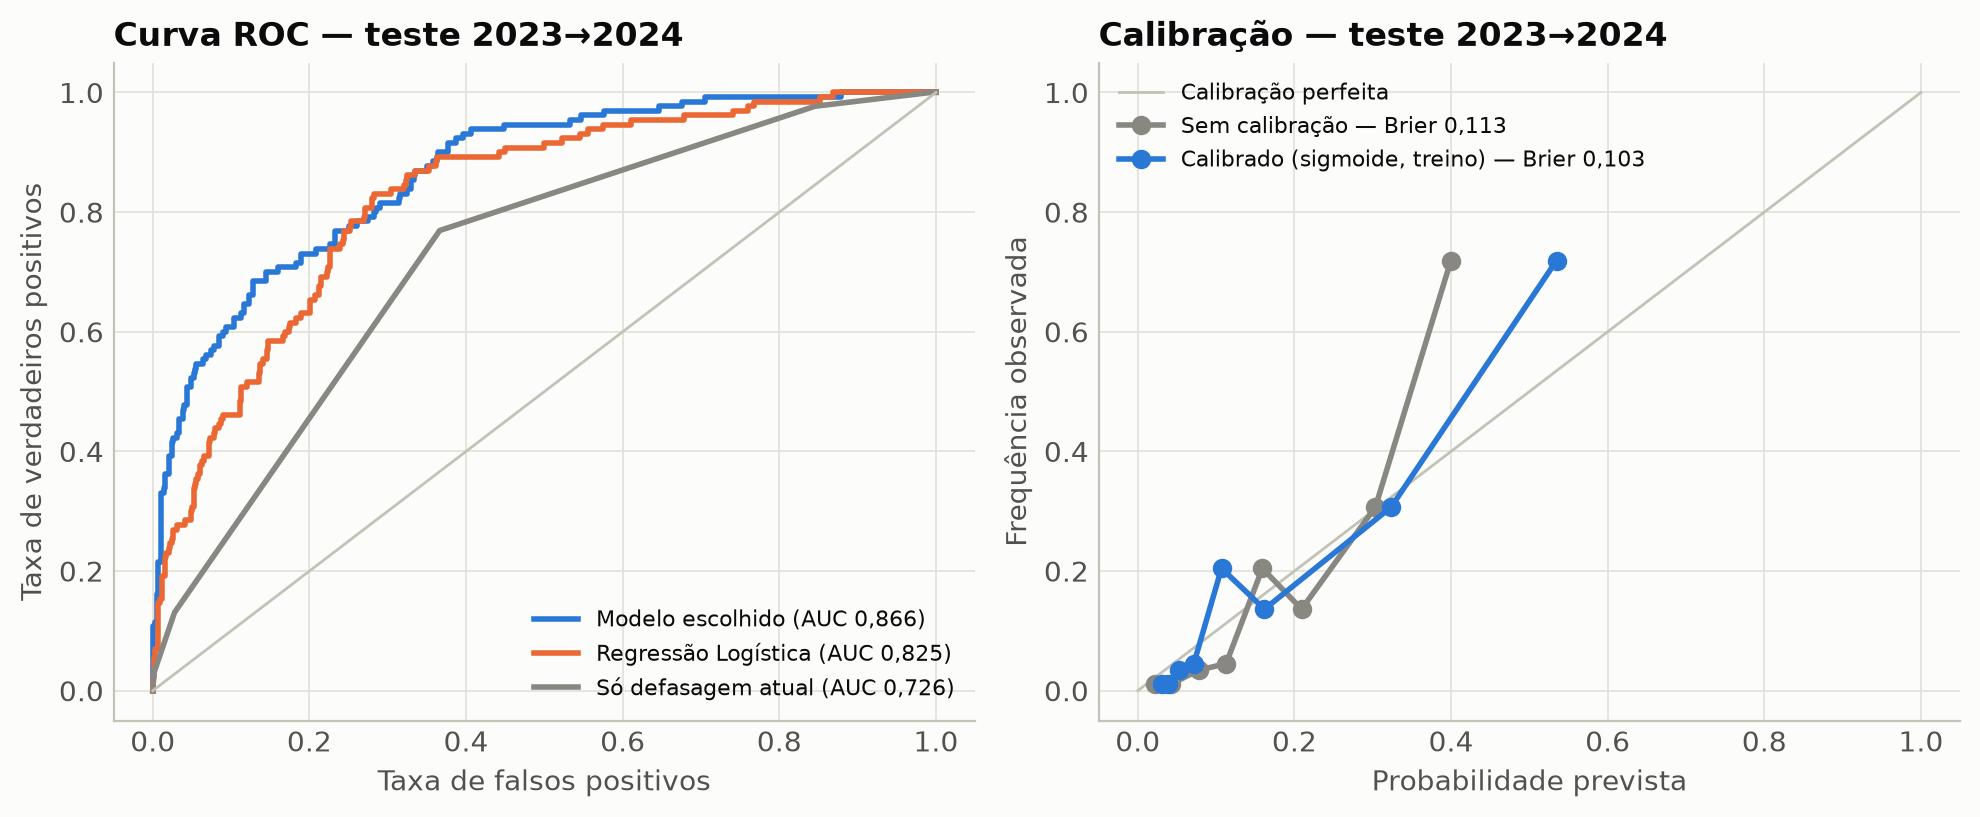

In [16]:
p_bruto = probs_teste[nome_escolhido]
fig, eixos = nova_figura(10, 4.2, ncols=2)
fpr, tpr, _ = roc_curve(y_teste, p_teste)
eixos[0].plot(fpr, tpr, color=SERIES[0], label=f"Modelo escolhido (AUC {fmt_br(roc_auc_score(y_teste, p_teste), 3)})")
fpr, tpr, _ = roc_curve(y_teste, probs_teste["Regressão Logística"])
eixos[0].plot(fpr, tpr, color=SERIES[1], label=f"Regressão Logística (AUC {fmt_br(roc_auc_score(y_teste, probs_teste['Regressão Logística']), 3)})")
fpr, tpr, _ = roc_curve(y_teste, X_teste["defasagem"])
eixos[0].plot(fpr, tpr, color=NEUTRO, label=f"Só defasagem atual (AUC {fmt_br(roc_auc_score(y_teste, X_teste['defasagem']), 3)})")
eixos[0].plot([0, 1], [0, 1], color="#c3c2b7", linewidth=1)
eixos[0].set_xlabel("Taxa de falsos positivos"); eixos[0].set_ylabel("Taxa de verdadeiros positivos")
eixos[0].set_title("Curva ROC — teste 2023→2024"); eixos[0].legend(loc="lower right", fontsize=8)
eixos[0].grid(axis="x", visible=True)

eixos[1].plot([0, 1], [0, 1], color="#c3c2b7", linewidth=1, label="Calibração perfeita")
for prob, cor, rotulo in [(p_bruto, NEUTRO, "Sem calibração"), (p_teste, SERIES[0], "Calibrado (sigmoide, treino)")]:
    frac, media = calibration_curve(y_teste, prob, n_bins=8, strategy="quantile")
    eixos[1].plot(media, frac, marker="o", markersize=6, color=cor, label=f"{rotulo} — Brier {fmt_br(brier_score_loss(y_teste, prob), 3)}")
eixos[1].set_xlabel("Probabilidade prevista"); eixos[1].set_ylabel("Frequência observada")
eixos[1].set_title("Calibração — teste 2023→2024"); eixos[1].legend(loc="upper left", fontsize=8)
eixos[1].grid(axis="x", visible=True)
salvar(fig, "q9_roc_calibracao")
Image(str(PASTA_FIGURAS / "q9_roc_calibracao.png"))

## 7. Interpretação

A importância por permutação, calculada no teste, mede quanto o ROC-AUC cai quando cada atributo é embaralhado. É **associação preditiva, não causalidade**.

In [17]:
imp = permutation_importance(modelo_treino, X_teste, y_teste, scoring="roc_auc", n_repeats=30, random_state=SEMENTE, n_jobs=-1)
importancias = pd.DataFrame({"queda_auc": imp.importances_mean, "dp": imp.importances_std}, index=ATRIBUTOS).sort_values("queda_auc", ascending=False)
importancias

,queda_auc,dp
idade,0.087,0.014
defasagem,0.032,0.009
IPV,0.027,0.004
idade_relativa_fase,0.020,0.006
IDA,0.008,0.002
anos_no_programa,0.008,0.003
mat,0.006,0.003
por,0.005,0.001
fase,0.004,0.002
inde,0.002,0.001


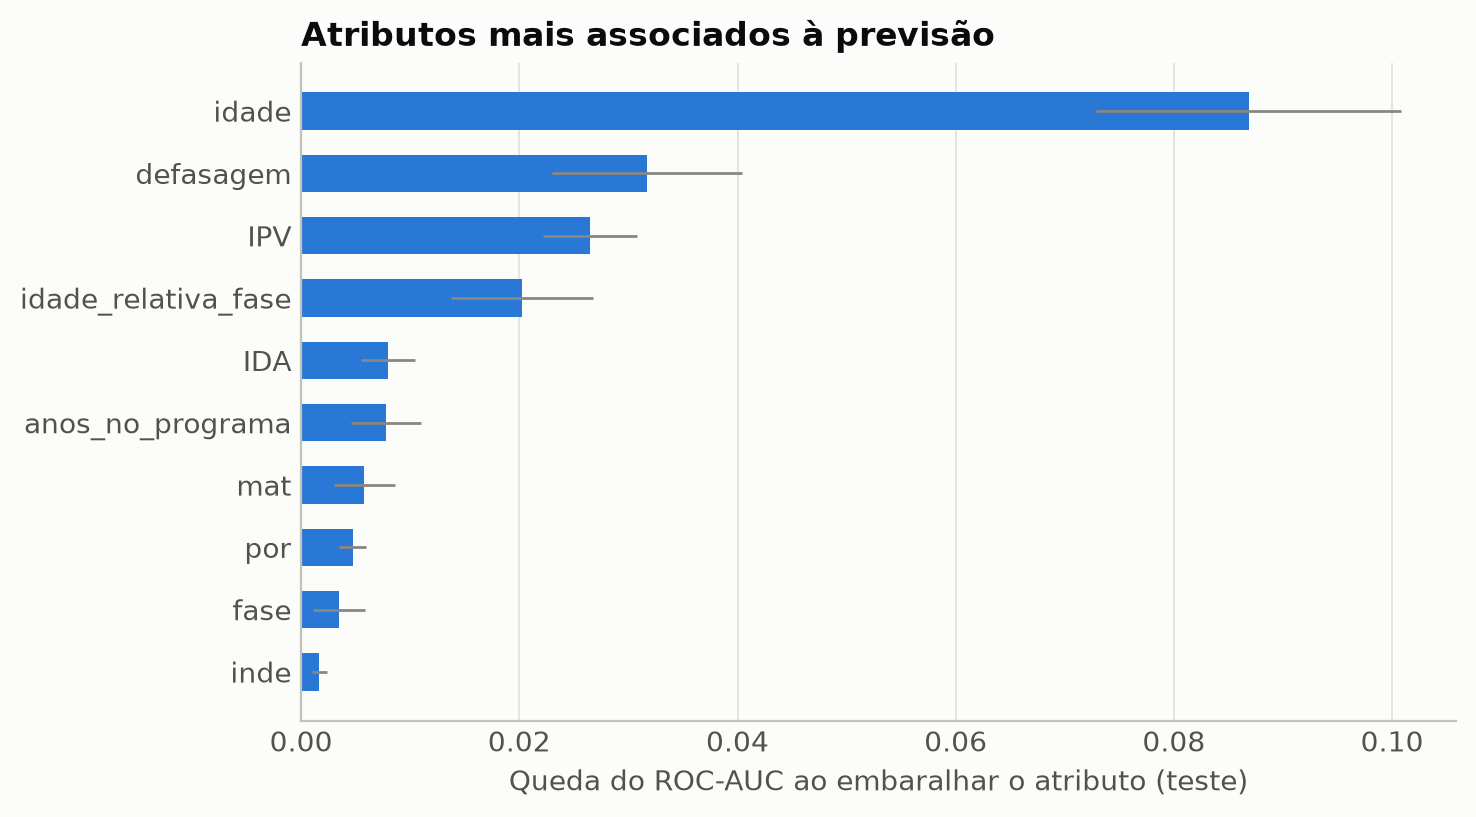

In [18]:
top = importancias.head(10).iloc[::-1]
fig, eixo = nova_figura(7.5, 4.2)
eixo.barh(range(len(top)), top["queda_auc"], xerr=top["dp"], color=SERIES[0], height=0.6,
          error_kw={"ecolor": "#898781", "elinewidth": 1})
eixo.set_yticks(range(len(top))); eixo.set_yticklabels(top.index)
eixo.grid(axis="y", visible=False); eixo.grid(axis="x", visible=True)
eixo.set_xlabel("Queda do ROC-AUC ao embaralhar o atributo (teste)")
eixo.set_title("Atributos mais associados à previsão")
salvar(fig, "q9_importancia")
Image(str(PASTA_FIGURAS / "q9_importancia.png"))

**O que a faixa Alto contém** (teste). Composição dos alunos sinalizados segundo o que de fato aconteceu. Descreve o grupo, não o motivo individual de cada sinalização.

In [19]:
teste_faixa = teste.assign(prob=p_teste, faixa=faixa_de_risco(p_teste, limiar_medio, limiar_alto),
                           desfecho=decompor_evento(teste))
composicao_alto = teste_faixa[teste_faixa["faixa"] == "Alto"]["desfecho"].value_counts()
composicao_alto.to_frame("alunos").assign(pct=lambda d: d["alunos"] / d["alunos"].sum() * 100)

,alunos,pct
desfecho,,
Sem evento,88,49.162
Entrada em defasagem,81,45.251
Agravamento (já defasado),9,5.028
Perda de vantagem (continua em fase),1,0.559


## 8. Robustez e sensibilidades

Nenhuma destas análises foi usada para escolher o modelo; elas mostram o quanto os resultados dependem das decisões tomadas.

In [20]:
alunos_treino = set(treino["ra"])
novos = ~teste["ra"].isin(alunos_treino)
inverso = clone(modelo_escolhido).fit(X_teste, y_teste)
robustez = pd.DataFrame([
    {"análise": "Teste completo", "n": len(teste), "prevalência": y_teste.mean(), "ROC-AUC": roc_auc_score(y_teste, p_teste)},
    {"análise": "Só alunos novos (fora do treino)", "n": int(novos.sum()), "prevalência": y_teste[novos].mean(),
     "ROC-AUC": roc_auc_score(y_teste[novos], p_teste[novos])},
    {"análise": "Só alunos já vistos no treino", "n": int((~novos).sum()), "prevalência": y_teste[~novos].mean(),
     "ROC-AUC": roc_auc_score(y_teste[~novos], p_teste[~novos])},
    {"análise": "Direção inversa (treina 23→24, testa 22→23)", "n": len(treino), "prevalência": y_treino.mean(),
     "ROC-AUC": roc_auc_score(y_treino, inverso.predict_proba(X_treino)[:, 1])},
]).set_index("análise")
robustez

,n,prevalência,ROC-AUC
análise,,,
Teste completo,706,0.184,0.866
Só alunos novos (fora do treino),255,0.341,0.890
Só alunos já vistos no treino,451,0.095,0.770
"Direção inversa (treina 23→24, testa 22→23)",600,0.173,0.843


**Sensibilidade à regra de fase ideal de 2024 (A01).** Em 2024, 301 registros da fonte têm fase ideal diferente da correspondência idade → fase observada em 2022 e 2023, e nenhuma data de referência única reproduz a regra de 2024. O cenário abaixo recalcula D com a regra de 2022/23 (coluna `defasagem_regra`). **É uma sensibilidade, não uma correção da fonte.** Os rótulos do treino não mudam, porque 2022 e 2023 seguem a mesma regra.

In [21]:
assert (treino[ALVO] == treino[ALVO_SENSIBILIDADE]).all()
y_teste_regra = teste[ALVO_SENSIBILIDADE]
sens_regra = {
    "rotulos_alterados_teste": int((y_teste != y_teste_regra).sum()),
    "eventos_fonte": int(y_teste.sum()), "eventos_regra": int(y_teste_regra.sum()),
    "roc_auc_rotulos_regra": float(roc_auc_score(y_teste_regra, p_teste)),
    "ic95_auc_rotulos_regra": bootstrap_ic(y_teste_regra, p_teste, roc_auc_score),
}
sens_regra

{'rotulos_alterados_teste': 69,
 'eventos_fonte': 130,
 'eventos_regra': 159,
 'roc_auc_rotulos_regra': 0.7829211364446438,
 'ic95_auc_rotulos_regra': [0.7462080674433581, 0.8197168652515758]}

**Sensibilidade a decisões de atributos (A10) e ao alvo anterior (A03).** Mesmo modelo base, mesmo protocolo (treino 2022→23, teste 2023→24), sem calibração, para isolar a ordenação.

In [22]:
def avaliar_variante(atributos, alvo=ALVO, dados_treino=treino, dados_teste=teste):
    m = clone(base_escolhida)
    prob_cv = cross_val_predict(m, dados_treino[atributos], dados_treino[alvo], cv=cv, method="predict_proba")[:, 1]
    p = m.fit(dados_treino[atributos], dados_treino[alvo]).predict_proba(dados_teste[atributos])[:, 1]
    return {"ROC-AUC (CV treino)": roc_auc_score(dados_treino[alvo], prob_cv), "ROC-AUC (teste)": roc_auc_score(dados_teste[alvo], p),
            "prevalência teste": dados_teste[alvo].mean(), "n teste": len(dados_teste)}

pares_s = pares.copy()
pares_s["IPS_z"] = pares_s.groupby("ano")["IPS"].transform(lambda s: (s - s.mean()) / s.std())
tr_s, te_s = pares_s[pares_s["ano"] == 2022], pares_s[pares_s["ano"] == 2023]
troca = lambda de, para: [para if a == de else a for a in ATRIBUTOS]
variantes = {
    "Especificação adotada": ATRIBUTOS,
    "IAA com zeros da fonte": troca("IAA", "IAA_fonte"),
    "Sem IAA": [a for a in ATRIBUTOS if a != "IAA"],
    "Sem INDE": [a for a in ATRIBUTOS if a != "inde"],
    "Com IPS (padronizado no ano)": ATRIBUTOS + ["IPS_z"],
}
sens_atributos = pd.DataFrame({nome: avaliar_variante(cols, dados_treino=tr_s, dados_teste=te_s) for nome, cols in variantes.items()}).T

# Alvo da versão anterior: queda de IDA >= 0,5 ou redução de D (mesma população, pares com IDA nos dois anos).
ida_seg = base[["ra", "ano", "IDA"]].assign(ano=lambda d: d["ano"] - 1).rename(columns={"IDA": "IDA_seguinte"})
pares_c = pares.merge(ida_seg, on=["ra", "ano"], validate="one_to_one").dropna(subset=["IDA", "IDA_seguinte"])
pares_c["alvo_composto"] = (((pares_c["IDA_seguinte"] - pares_c["IDA"]) <= -0.5) | (pares_c[ALVO] == 1)).astype(int)
tr_c, te_c = pares_c[pares_c["ano"] == 2022], pares_c[pares_c["ano"] == 2023]
sens_atributos.loc["Alvo anterior (queda IDA ≥ 0,5 ou redução de D)"] = pd.Series(
    avaliar_variante(ATRIBUTOS, "alvo_composto", tr_c, te_c))
sens_atributos

,ROC-AUC (CV treino),ROC-AUC (teste),prevalência teste,n teste
Especificação adotada,0.832,0.866,0.184,706.000
IAA com zeros da fonte,0.833,0.865,0.184,706.000
Sem IAA,0.832,0.864,0.184,706.000
Sem INDE,0.835,0.861,0.184,706.000
Com IPS (padronizado no ano),0.828,0.865,0.184,706.000
"Alvo anterior (queda IDA ≥ 0,5 ou redução de D)",0.678,0.592,0.587,682.000


## 9. Modelo final e exportação

Para uso em produção (prever 2025 com o fechamento de 2024), o modelo é **reajustado com todos os pares** (2022→23 e 2023→24), com a mesma especificação e calibração. Como um aluno pode aparecer nas duas transições, a calibração e os limiares do modelo final usam **validação cruzada agrupada por aluno**.

**O modelo final não tem teste futuro.** A expectativa de desempenho vem do teste temporal da seção 6 e da validação cruzada agrupada abaixo.

In [23]:
X_todos, y_todos, grupos = pares[ATRIBUTOS], pares[ALVO], pares["ra"]
divisoes = list(GroupKFold(n_splits=5).split(X_todos, y_todos, grupos))
prob_oof_todos = np.zeros(len(pares))
for i_treino, i_valid in divisoes:
    internas = list(GroupKFold(n_splits=5).split(X_todos.iloc[i_treino], y_todos.iloc[i_treino], grupos.iloc[i_treino]))
    m = calibrado(base_escolhida, internas).fit(X_todos.iloc[i_treino], y_todos.iloc[i_treino])
    prob_oof_todos[i_valid] = m.predict_proba(X_todos.iloc[i_valid])[:, 1]
limiar_medio_final, limiar_alto_final = limiares(y_todos, prob_oof_todos)
cv_final = {"roc_auc": float(roc_auc_score(y_todos, prob_oof_todos)), "ap": float(average_precision_score(y_todos, prob_oof_todos)),
            "brier": float(brier_score_loss(y_todos, prob_oof_todos)), "n": int(len(pares))}
modelo_final = calibrado(base_escolhida, divisoes).fit(X_todos, y_todos)
print(f"CV agrupada por aluno (todos os pares): ROC-AUC {cv_final['roc_auc']:.3f} | AP {cv_final['ap']:.3f} | Brier {cv_final['brier']:.3f}")
print(f"Limiares do modelo final: médio {limiar_medio_final:.3f} | alto {limiar_alto_final:.3f}")

CV agrupada por aluno (todos os pares): ROC-AUC 0.869 | AP 0.576 | Brier 0.104
Limiares do modelo final: médio 0.124 | alto 0.175


In [24]:
# Alunos de 2024, fases 0–7: risco para 2025, condicional a permanecerem na base.
# Dado individual (por RA): gravado em data/processed/, que não é versionado.
alunos_2024 = preparar_atributos(base[(base["ano"] == 2024) & (base["fase"] <= 7)])
alunos_2024 = alunos_2024.assign(probabilidade=modelo_final.predict_proba(alunos_2024[ATRIBUTOS])[:, 1])
alunos_2024["faixa"] = faixa_de_risco(alunos_2024["probabilidade"], limiar_medio_final, limiar_alto_final)
alunos_2024[["ra", "fase", "idade", "defasagem", "IDA", "IEG", "IPV", "inde", "probabilidade", "faixa"]] \
    .sort_values("probabilidade", ascending=False).to_csv(PASTA_PROCESSADOS / "q9_risco_alunos_2024.csv", index=False, encoding="utf-8-sig")
alunos_2024["faixa"].value_counts().reindex(["Alto", "Médio", "Baixo"])

faixa
Alto     367
Médio    141
Baixo    546
Name: count, dtype: int64

In [25]:
def estrito(objeto):
    if isinstance(objeto, dict):
        return {str(k): estrito(v) for k, v in objeto.items()}
    if isinstance(objeto, (list, tuple)):
        return [estrito(v) for v in objeto]
    if isinstance(objeto, (np.bool_,)):
        return bool(objeto)
    if isinstance(objeto, (np.integer,)):
        return int(objeto)
    if isinstance(objeto, (float, np.floating)):
        return None if not np.isfinite(objeto) else float(objeto)
    return objeto

metr_alto, metr_medio = metricas(y_teste, p_teste, limiar_alto), metricas(y_teste, p_teste, limiar_medio)
LIMITACOES = [
    "Probabilidade condicional a o aluno aparecer na base do ano seguinte; não estima risco de saída.",
    "Evento = redução de D (fase efetiva − fase ideal); inclui entrada em defasagem, agravamento e perda de vantagem.",
    "A regra de fase ideal de 2024 difere da de 2022/23 em 301 registros; ver sensibilidade.",
    "A calibração varia por fase (ex.: Fase 5 subestimada no teste); use a faixa e a ordenação, não o valor exato.",
    "Modelo final retreinado sem teste futuro; usar indicadores do fechamento do ano anterior.",
]
pacote = {
    "modelo": modelo_final, "atributos": ATRIBUTOS,
    "limiar_medio": limiar_medio_final, "limiar_alto": limiar_alto_final,
    "nome_modelo": f"{nome_escolhido} + calibração sigmoide", "versao_sklearn": sklearn.__version__,
    "treinado_com": "pares 2022→2023 e 2023→2024 (fases 0–7)", "uso": "fechamento do ano t → risco em t+1",
    "evento": "redução de D = fase efetiva − fase ideal no ano seguinte", "limitacoes": LIMITACOES,
    "medianas_referencia": pares[ATRIBUTOS].median().to_dict(),
}
MODELO_RISCO.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(pacote, MODELO_RISCO, compress=3)

resultados = {
    "alvo": "redução de D (fase efetiva − fase ideal) no ano seguinte, fases 0–7",
    "populacao": "alunos presentes em t e t+1; previsão condicional à permanência na base",
    "pares_treino": len(treino), "pares_teste": len(teste),
    "prevalencia_treino": y_treino.mean(), "prevalencia_teste": y_teste.mean(),
    "decomposicao_evento": {str(k): v for k, v in decomposicao.to_dict(orient="index").items()},
    "promocao_x_evento": {"nao_promovidos": int((~pares["promovido"]).sum()),
                          "nao_promovidos_sem_evento": int(((~pares["promovido"]) & (pares[ALVO] == 0)).sum()),
                          "promovidos": int(pares["promovido"].sum()),
                          "promovidos_com_evento": int((pares["promovido"] & (pares[ALVO] == 1)).sum())},
    "modelo_escolhido": f"{nome_escolhido} + calibração sigmoide",
    "selecao_cv": selecao.reset_index().to_dict(orient="records"),
    "teste": tabela_teste.reset_index().to_dict(orient="records"),
    "teste_modelo_escolhido": {"roc_auc": roc_auc_score(y_teste, p_teste), "roc_auc_ic95": ic_auc,
                               "ap": average_precision_score(y_teste, p_teste), "ap_ic95": ic_ap,
                               "brier": brier_score_loss(y_teste, p_teste), "brier_sem_calibracao": brier_score_loss(y_teste, p_bruto)},
    "limiar_alto": limiar_alto, "limiar_medio": limiar_medio,
    "metricas_alto": metr_alto, "metricas_medio": metr_medio,
    "captura_top": tabela_captura.reset_index().to_dict(orient="records"),
    "calibracao_por_fase": calib_fase.reset_index().rename(columns={"index": "fase"}).to_dict(orient="records"),
    "importancia_permutacao": importancias["queda_auc"].round(4).to_dict(),
    "composicao_faixa_alto": composicao_alto.to_dict(),
    "robustez": robustez.reset_index().to_dict(orient="records"),
    "sensibilidade_regra_2024": sens_regra,
    "sensibilidade_atributos": sens_atributos.reset_index().rename(columns={"index": "variante"}).to_dict(orient="records"),
    "modelo_final": {"cv_agrupada": cv_final, "limiar_medio": limiar_medio_final, "limiar_alto": limiar_alto_final,
                     "alunos_2024_por_faixa": alunos_2024["faixa"].value_counts().to_dict(), "n_alunos_2024": len(alunos_2024)},
    "limitacoes": LIMITACOES,
}
with open(RESULTADOS_MODELO, "w", encoding="utf-8") as f:
    json.dump(estrito(resultados), f, ensure_ascii=False, indent=2, allow_nan=False)
print("Modelo salvo em", MODELO_RISCO.relative_to(RAIZ))
print("Resultados em", RESULTADOS_MODELO.relative_to(RAIZ))

Modelo salvo em models/modelo_risco_defasagem.joblib
Resultados em outputs/resultados_modelo.json


## 10. Conclusões e limitações

Os números estão nas saídas acima e em `outputs/resultados_modelo.json`, que alimenta o documento final.

**O que o modelo demonstra**
- No teste temporal, o modelo **ordena** bem os alunos pelo risco de redução de D, acima do baseline que usa só a defasagem atual. A direção inversa (treino 2023→24, teste 2022→23) também mantém boa ordenação.
- O uso mais defensável é a **priorização**: acompanhar primeiro os alunos com maior risco estimado.

**O que o modelo não demonstra**
- **Causalidade.** A importância por permutação é associação preditiva.
- **Probabilidade individual confiável em todas as fases.** Mesmo com calibração, há fases com diferença grande entre previsto e observado (tabela da seção 6). A promoção no Ensino Médio mudou entre os anos.
- **Risco para quem sai da base.** A previsão é condicional a o aluno aparecer no ano seguinte.
- **Que o aluno sinalizado vá "entrar em defasagem".** O evento inclui entrada, agravamento e perda de vantagem; a composição da faixa Alto está na seção 7.

**Dependências documentadas**
- Regra de fase ideal de 2024 (sensibilidade na seção 8).
- Tratamento de IAA = 0, exclusão de IPS e uso do INDE oficial (sensibilidades na seção 8).
- Formulação do alvo escolhida após consultar 2023→24 (ver introdução).
- Apenas duas transições anuais; o modelo final não tem teste futuro.